In [1]:
from sklearn.datasets import fetch_20newsgroups

docs = fetch_20newsgroups(subset='all',  remove=('headers', 'footers', 'quotes'))['data']

from datasets import load_dataset
db = load_dataset("ag_news",split="train")
docs = db["text"]

/info/etu/m2/s2101052/miniconda3/envs/ETE/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
type(docs)

datasets.arrow_dataset.Column

In [3]:
from embeddingTopicEvaluatorLib.models.bertopic_wrapper import TopicModelEvaluatorBERTopic
from embeddingTopicEvaluatorLib.metrics.diversity import diversity
from embeddingTopicEvaluatorLib.config.config import settings

2026-03-06 10:47:16.917355: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-06 10:47:16.968151: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-06 10:47:19.790022: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


2026-03-06 10:47:33,306 - BERTopic - Embedding - Transforming documents to embeddings.
Batches:  64%|██████▍   | 2393/3750 [02:11<00:54, 24.91it/s]2026-03-06 10:51:57,896 - BERTopic - Dimensionality - Completed ✓
2026-03-06 10:51:57,901 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-06 10:52:04,442 - BERTopic - Cluster - Completed ✓
2026-03-06 10:52:04,443 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-06 10:52:07,103 - BERTopic - Representation - Completed ✓
2026-03-06 10:52:07,105 - BERTopic - Topic reduction - Reducing number of topics
2026-03-06 10:52:07,237 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-06 10:52:09,407 - BERTopic - Representation - Completed ✓
2026-03-06 10:52:09,420 - BERTopic - Topic reduction - Reduced number of topics from 594 to 50


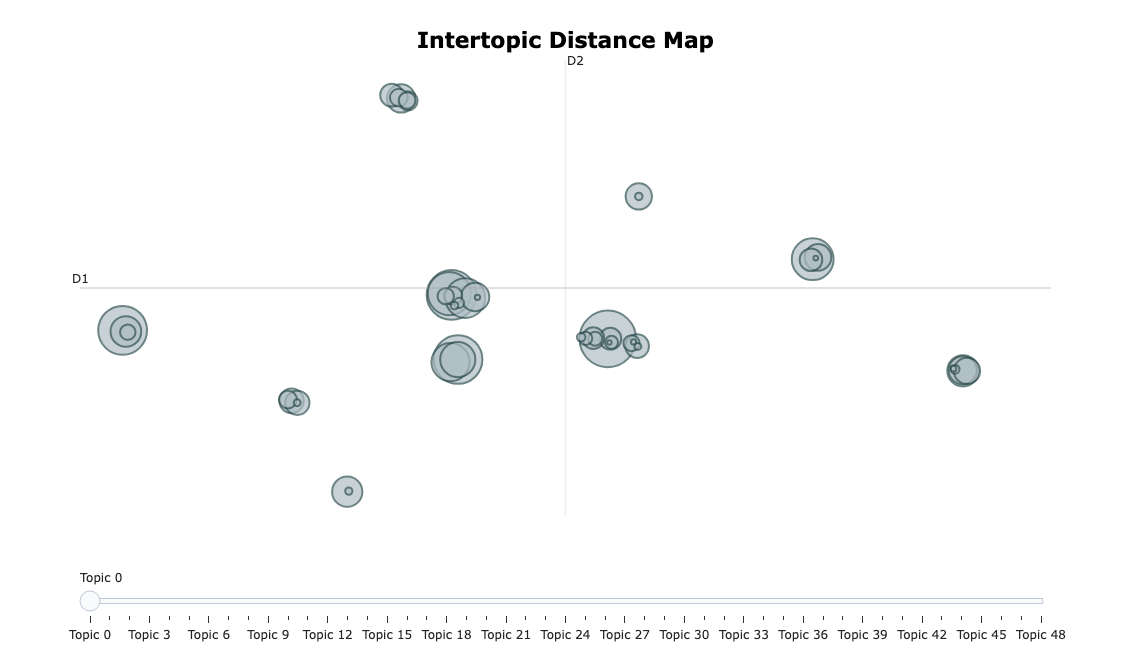

In [4]:
topic_model_hdbscan = TopicModelEvaluatorBERTopic()
topics_hdbscan, probs_hdbscan = topic_model_hdbscan.evaluate(docs)
#topic_model_hdbscan.get_topic_info()
#topic_model_hdbscan.get_topics().keys()
#print(diversity(topic_model_hdbscan))
topic_model_hdbscan.model.visualize_topics()
#topic_model_hdbscan.visualize_barchart()

2026-03-06 10:52:17,879 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 3750/3750 [03:00<00:00, 20.77it/s]
2026-03-06 10:55:22,368 - BERTopic - Embedding - Completed ✓
2026-03-06 10:55:22,370 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-06 10:56:24,714 - BERTopic - Dimensionality - Completed ✓
2026-03-06 10:56:24,719 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-06 10:56:25,992 - BERTopic - Cluster - Completed ✓
2026-03-06 10:56:25,993 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-06 10:56:28,391 - BERTopic - Representation - Completed ✓
2026-03-06 10:56:28,394 - BERTopic - Topic reduction - Reducing number of topics
2026-03-06 10:56:28,476 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-06 10:56:30,742 - BERTopic - Representation - Completed ✓
2026-03-06 10:56:30,753 - BERTopic - Topic reduction - 

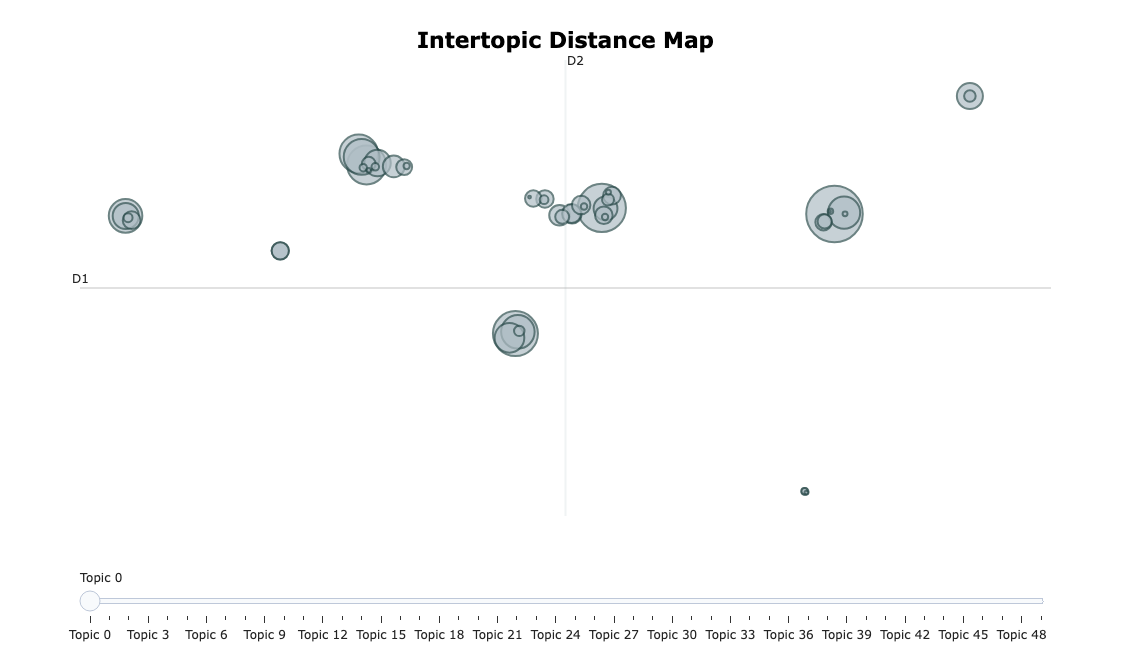

In [5]:
topic_model_KMean = TopicModelEvaluatorBERTopic(settings.BERTOPIC_CONFIG_KMeans)
topics_KMean, probs_hdbscan = topic_model_KMean.evaluate(docs)
#topic_model_KMeans.get_topic_info()
#topic_model_KMeans.get_topics().keys()
#print(diversity(print(diversity(topic_model_KMean))))
topic_model_KMean.model.visualize_topics()
#topic_model_KMeans.visualize_barchart()

In [6]:
topic_model_KMean.get_topics()

AttributeError: 'TopicModelEvaluatorBERTopic' object has no attribute 'get_topics'

In [ ]:
diversity(topic_model_KMean)

In [ ]:
diversity(topic_model_hdbscan)

In [ ]:
from sklearn.metrics.pairwise import manhattan_distances

diversity(topic_model_hdbscan,distance=manhattan_distances ,maximise=False)

In [ ]:
topic_model_hdbscan.get_topics().keys()

In [ ]:
topic_model_hdbscan.visualize_barchart()